In [1]:
import shutil, time
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from pathlib import Path

CLASSES    = ["normal","trespassing","loitering","object_abandonment"]
DRIVE_TEST = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/test")
LOCAL_TEST = Path("/content/xai_test")
WORKERS    = 64

all_files = [(f, LOCAL_TEST / f.relative_to(DRIVE_TEST))
             for f in DRIVE_TEST.rglob("*.jpg")]

n_local = len(list(LOCAL_TEST.rglob("*.jpg"))) if LOCAL_TEST.exists() else 0
if n_local == len(all_files) and n_local > 0:
    print(f"✓ Zaten var: {n_local} jpg")
else:
    def copy_file(args):
        src, dst = args
        dst.parent.mkdir(parents=True, exist_ok=True)
        if not dst.exists(): shutil.copy2(str(src), str(dst))
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=WORKERS) as ex:
        list(tqdm(ex.map(copy_file, all_files), total=len(all_files)))
    print(f"✓ {time.time()-t0:.0f}sn  {len(all_files)} jpg")

100%|██████████| 10446/10446 [02:02<00:00, 85.38it/s]

✓ 123sn  10446 jpg


In [22]:
# ═══════════════════════════════════════════════════════════
# HÜCRE 2: Model + GradCAM++ — klasik JET overlay
# Kernel restart sonrası çalıştır
# ═══════════════════════════════════════════════════════════
import torch, torch.nn as nn, numpy as np, cv2
import matplotlib.pyplot as plt
from torchvision.models.video import r3d_18
from torch.amp import autocast
from pathlib import Path
import random

CLASSES    = ["normal","trespassing","loitering","object_abandonment"]
DEVICE     = torch.device("cuda")
LOCAL_TEST = Path("/content/xai_test")
SAVE_DIR   = Path("/content/drive/MyDrive/archive/gradcam_results")
MODEL_PATH = "/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn_multilabel_final_model/best_model.pth"
MEAN       = np.array([0.485,0.456,0.406], dtype=np.float32)
STD        = np.array([0.229,0.224,0.225], dtype=np.float32)
COLORS     = {"normal":"#4CAF50","trespassing":"#F44336",
              "loitering":"#FF9800","object_abandonment":"#9C27B0"}
FRAME_IDXS = [0, 5, 10, 15]
SAVE_DIR.mkdir(parents=True, exist_ok=True)
random.seed(42)

# ── Model ─────────────────────────────────────────────────
model = r3d_18(weights=None)
model.fc = nn.Sequential(nn.Dropout(0.5),
                          nn.Linear(model.fc.in_features, 4))
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model = model.to(DEVICE).eval()
print(f"✓ Model  val_f1={ckpt['val_f1']:.4f}")

# ── Hook — layer3 ─────────────────────────────────────────
_act = {}
model.layer3[1].conv2.register_forward_hook(
    lambda m, i, o: _act.update({"v": o})
)

# ── GradCAM++ ─────────────────────────────────────────────
def safe_gradcam(clip_t, target_class):
    model.eval()
    inp    = clip_t.unsqueeze(0).to(DEVICE)
    logits = model(inp)
    probs  = torch.sigmoid(logits)[0]
    act    = _act["v"]
    try:
        grads = torch.autograd.grad(
            logits[0, target_class], act,
            retain_graph=True, create_graph=False
        )[0][0]
    except Exception:
        return None, probs.detach().cpu().numpy()
    acts  = act[0].detach()
    gsq   = grads**2; gcu = grads**3
    denom = 2*gsq + (acts*gcu).sum(dim=(2,3),keepdim=True)
    denom = torch.where(denom!=0, denom, torch.ones_like(denom))
    alpha = gsq/denom
    w     = (alpha*torch.relu(grads)).mean(dim=(2,3),keepdim=True)
    cam   = torch.relu((w*acts).sum(0)).cpu().numpy()
    if cam.max()<=1e-6: return None, probs.detach().cpu().numpy()
    cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
    return cam, probs.detach().cpu().numpy()

# ── Klasik JET overlay — tüm görüntüye, maskesiz ─────────
def overlay_heatmap(frame_rgb, cam_2d, alpha=0.5):
    H, W        = frame_rgb.shape[:2]
    cam_r       = cv2.resize(cam_2d.astype(np.float32),(W,H))
    heatmap     = cv2.applyColorMap((cam_r*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return (alpha*heatmap + (1-alpha)*frame_rgb).astype(np.uint8)

def get_cam_frame(cam, fi):
    T = cam.shape[0]
    return cam[min(int(fi*T/16),T-1)]

print("✓ GradCAM++ hazır — klasik JET overlay")

✓ Model  val_f1=0.9860
✓ GradCAM++ hazır — klasik JET overlay


In [23]:
# ═══════════════════════════════════════════════════════════
# HÜCRE 3: Inference + seçim
# ═══════════════════════════════════════════════════════════
from torch.amp import autocast

def load_clip(clip_dir, n_frames=16, size=112):
    jpgs = sorted(Path(clip_dir).glob("*.jpg"))[:n_frames]
    if len(jpgs)<n_frames: return None,None
    fo,fm=[],[]
    for fp in jpgs:
        img=cv2.imread(str(fp))
        if img is None: return None,None
        rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        fo.append(rgb); fm.append(cv2.resize(rgb,(size,size)))
    arr=(np.stack(fm).astype(np.float32)/255.0-MEAN)/STD
    return torch.from_numpy(arr.transpose(3,0,1,2)).float(), fo

def predict(clip_t):
    with torch.no_grad():
        with autocast('cuda'):
            logits=model(clip_t.unsqueeze(0).to(DEVICE))
        probs=torch.sigmoid(logits).cpu().numpy()[0]
    return int(probs.argmax()), probs

print("Inference...")
all_clips=[]
for ci,cls in enumerate(CLASSES):
    d=LOCAL_TEST/cls
    if not d.exists(): continue
    for cd in sorted([f.parent for f in d.rglob("frame_001.jpg")]):
        clip_t,frames=load_clip(cd)
        if clip_t is None: continue
        pred,probs=predict(clip_t)
        all_clips.append({"cls":cls,"cls_idx":ci,"clip_dir":cd,
                           "clip_t":clip_t,"frames_orig":frames,
                           "pred":pred,"pred_name":CLASSES[pred],
                           "probs":probs,"correct":pred==ci})
print(f"✓ {len(all_clips)} klip")

selected=[]
for ci,cls in enumerate(CLASSES):
    cor=sorted([c for c in all_clips if c["cls_idx"]==ci and c["correct"]],
               key=lambda x:x["probs"][ci],reverse=True)
    wrg=sorted([c for c in all_clips if c["cls_idx"]==ci and not c["correct"]],
               key=lambda x:-x["probs"][x["pred"]])
    for c in ([cor[0],cor[len(cor)//2]] if len(cor)>=2 else cor[:1]):
        c["role"]="doğru"; selected.append(c)
    for c in wrg[:2]:
        c["role"]="yanlış"; selected.append(c)

print(f"✓ {len(selected)} seçildi:")
for c in selected:
    a="+".join([CLASSES[j][:3].upper() for j in range(4) if c["probs"][j]>0.5]) or "?"
    print(f"  {'✓' if c['role']=='doğru' else '✗'} {c['cls']:<22}→{c['pred_name']:<22}[{a}] {c['probs'][c['pred']]:.3f}")

Inference...
✓ 311 klip
✓ 14 seçildi:
  ✓ normal                →normal                [NOR] 1.000
  ✓ normal                →normal                [NOR] 0.999
  ✗ normal                →trespassing           [TRE] 0.896
  ✗ normal                →trespassing           [TRE] 0.876
  ✓ trespassing           →trespassing           [TRE] 1.000
  ✓ trespassing           →trespassing           [TRE] 1.000
  ✓ loitering             →loitering             [LOI] 1.000
  ✓ loitering             →loitering             [LOI] 0.951
  ✗ loitering             →normal                [NOR] 0.965
  ✗ loitering             →object_abandonment    [OBJ] 0.897
  ✓ object_abandonment    →object_abandonment    [OBJ] 1.000
  ✓ object_abandonment    →object_abandonment    [OBJ] 0.994
  ✗ object_abandonment    →loitering             [LOI] 0.979
  ✗ object_abandonment    →loitering             [LOI+OBJ] 0.974


In [24]:
# ═══════════════════════════════════════════════════════════
# KOD 1: Seçili klipler — klasik GradCAM++ → archive kaydet
# ═══════════════════════════════════════════════════════════
save_c1 = SAVE_DIR/"code1_selected"
save_c1.mkdir(parents=True, exist_ok=True)
print(f"GradCAM++ ({len(selected)} klip) → {save_c1}\n")

for clip_info in selected:
    cls       = clip_info["cls"]
    pred_name = clip_info["pred_name"]
    role      = clip_info["role"]
    clip_t    = clip_info["clip_t"]
    frames    = clip_info["frames_orig"]
    probs     = clip_info["probs"]
    is_normal = (cls=="normal")
    clip_name = clip_info["clip_dir"].name

    active_idx=[i for i in range(4) if probs[i]>0.5]
    if not active_idx: active_idx=[int(probs.argmax())]

    cam_dict={}
    for ai in active_idx:
        cam,_=safe_gradcam(clip_t,ai)
        cam_dict[ai]=cam

    if len(active_idx)>=2:
        cv=[cam_dict[ai] for ai in active_idx if cam_dict[ai] is not None]
        if len(cv)>=2:
            T=min(c.shape[0] for c in cv)
            dif=np.abs(cv[0][:T]-cv[1][:T])
            dif=(dif-dif.min())/(dif.max()-dif.min()+1e-8)
            cam_dict["diff"]=dif

    rows=["orig"] if is_normal else ["orig"]+active_idx
    if "diff" in cam_dict: rows.append("diff")

    fig,axes=plt.subplots(len(rows),4,figsize=(16,len(rows)*3.2))
    axes=np.array(axes).reshape(len(rows),4)

    for ri,rk in enumerate(rows):
        for col,fi in enumerate(FRAME_IDXS):
            ax=axes[ri][col]; frame=frames[fi]
            if rk=="orig":
                ax.imshow(frame)
                if col==0: ax.set_ylabel("Orijinal",fontsize=8)
            elif rk=="diff":
                cam=cam_dict["diff"]
                ax.imshow(overlay_heatmap(frame,get_cam_frame(cam,fi),alpha=0.5))
                if col==0: ax.set_ylabel("Fark\n(A-B)",fontsize=7,color="teal")
            else:
                cam=cam_dict.get(rk)
                if cam is not None:
                    ax.imshow(overlay_heatmap(frame,get_cam_frame(cam,fi),alpha=0.5))
                else:
                    ax.imshow(frame)
                    ax.text(0.5,0.5,"boş",ha='center',va='center',
                            transform=ax.transAxes,fontsize=9,color='red')
                if col==0:
                    ax.set_ylabel(f"GradCAM++\n{CLASSES[rk][:8]}",
                                  fontsize=7,color=COLORS[CLASSES[rk]])
            ax.axis('off')
            if ri==0: ax.set_title(f"Frame #{fi+1}",fontsize=8,pad=2)

    status=("DOGRU" if role=="doğru" else "YANLIS")
    tc=("#2E7D32" if role=="doğru" else "#C62828")
    pb="  ".join([f"{CLASSES[j][0].upper()}:{probs[j]:.2f}" for j in range(4)])
    ac="+".join([CLASSES[i][:3].upper() for i in active_idx])
    fig.suptitle(
        f"{'DOĞRU' if role=='doğru' else 'YANLIŞ'}  |  Gerçek:{cls.upper()}  "
        f"Aktif:[{ac}]  Tahmin:{pred_name.upper()}\n[{pb}]",
        fontsize=10,fontweight='bold',color=tc,y=1.01)
    plt.tight_layout()
    fname=f"{status}_{cls}_{clip_name[:30]}.png"
    plt.savefig(str(save_c1/fname),dpi=120,bbox_inches='tight')
    plt.show(); print(f"  ✓ {fname}"); print()

print(f"\n✓ Kod 1 → {save_c1}")

Output hidden; open in https://colab.research.google.com to view.

In [25]:
# ═══════════════════════════════════════════════════════════
# KOD 2: 8 sınıf × 5 örnek — klasik GradCAM++ → archive
# ═══════════════════════════════════════════════════════════
import random,numpy as np,cv2,torch
import matplotlib.pyplot as plt
from pathlib import Path
from torch.amp import autocast

XAI_TEST   = Path("/content/xai_test")
DRIVE_TEST = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/test")
save_c2    = SAVE_DIR/"code2_8classes"
save_c2.mkdir(parents=True,exist_ok=True)

ALL_CLASSES=[
    "normal","trespassing","loitering","object_abandonment",
    "loitering+trespassing","loitering+object_abandonment",
    "trespassing+object_abandonment",
    "loitering+trespassing+object_abandonment",
]
COMP_LABELS={
    "loitering+trespassing":                    [0,1,1,0],
    "loitering+object_abandonment":             [0,0,1,1],
    "trespassing+object_abandonment":           [0,1,0,1],
    "loitering+trespassing+object_abandonment": [0,1,1,1],
}
N_SAMPLES=5; random.seed(42)

def load_clip_from_dir(clip_dir,size=112):
    jpgs=sorted(clip_dir.glob("*.jpg"))[:16]
    if len(jpgs)<8: return None,None
    fo,fm=[],[]
    for fp in jpgs:
        img=cv2.imread(str(fp))
        if img is None: return None,None
        rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        fo.append(rgb); fm.append(cv2.resize(rgb,(size,size)))
    while len(fm)<16: fm.append(fm[-1]); fo.append(fo[-1])
    arr=(np.stack(fm).astype(np.float32)/255.0-MEAN)/STD
    return torch.from_numpy(arr.transpose(3,0,1,2)).float(),fo

def get_active_orig(cls_name):
    if cls_name in CLASSES: return [CLASSES.index(cls_name)]
    return [i for i,v in enumerate(COMP_LABELS.get(cls_name,[])) if v==1]

print(f"→ {save_c2}\n")

for cls_name in ALL_CLASSES:
    cls_dir=XAI_TEST/cls_name if cls_name in CLASSES else DRIVE_TEST/cls_name
    if not cls_dir.exists(): print(f"[YOK] {cls_name}"); continue
    all_clips=[f.parent for f in cls_dir.rglob("frame_001.jpg")]
    if not all_clips: print(f"[BOŞ] {cls_name}"); continue

    samples=random.sample(all_clips,min(N_SAMPLES,len(all_clips)))
    is_normal=(cls_name=="normal")
    active_orig=get_active_orig(cls_name)
    cls_save=save_c2/cls_name; cls_save.mkdir(parents=True,exist_ok=True)

    print(f"\n{'='*55}\n  {cls_name.upper()}  ({len(all_clips)} klip)\n{'='*55}")

    for si,clip_dir in enumerate(samples):
        clip_t,frames=load_clip_from_dir(clip_dir)
        if clip_t is None: print(f"  [ATLA] {clip_dir.name}"); continue

        with torch.no_grad():
            with autocast('cuda'):
                logits=model(clip_t.unsqueeze(0).to(DEVICE))
            probs=torch.sigmoid(logits).cpu().numpy()[0]
        pred_idx=int(probs.argmax()); pred_name=CLASSES[pred_idx]

        cam_dict={}
        for ai in active_orig:
            cam,_=safe_gradcam(clip_t,ai); cam_dict[ai]=cam

        if len(active_orig)>=2:
            cv=[cam_dict[ai] for ai in active_orig if cam_dict[ai] is not None]
            if len(cv)>=2:
                T=min(c.shape[0] for c in cv)
                dif=np.abs(cv[0][:T]-cv[1][:T])
                dif=(dif-dif.min())/(dif.max()-dif.min()+1e-8)
                cam_dict["diff"]=dif

        active_sig=[i for i in range(4) if probs[i]>0.5]
        if not active_sig: active_sig=[pred_idx]

        rows=["orig"] if is_normal else ["orig"]+active_orig
        if "diff" in cam_dict: rows.append("diff")

        fig,axes=plt.subplots(len(rows),4,figsize=(16,len(rows)*3.2))
        axes=np.array(axes).reshape(len(rows),4)

        for ri,rk in enumerate(rows):
            for col,fi in enumerate(FRAME_IDXS):
                ax=axes[ri][col]; frame=frames[fi]
                if rk=="orig":
                    ax.imshow(frame)
                    if col==0: ax.set_ylabel("Orijinal",fontsize=8)
                elif rk=="diff":
                    cam=cam_dict["diff"]
                    ax.imshow(overlay_heatmap(frame,get_cam_frame(cam,fi),alpha=0.5))
                    if col==0: ax.set_ylabel("Fark\n(A-B)",fontsize=7,color="teal")
                else:
                    cam=cam_dict.get(rk)
                    if cam is not None:
                        ax.imshow(overlay_heatmap(frame,get_cam_frame(cam,fi),alpha=0.5))
                    else:
                        ax.imshow(frame)
                        ax.text(0.5,0.5,"boş",ha='center',va='center',
                                transform=ax.transAxes,fontsize=9,color='red')
                    if col==0:
                        ax.set_ylabel(f"GradCAM++\n{CLASSES[rk][:8]}",
                                      fontsize=7,color=COLORS[CLASSES[rk]])
                ax.axis('off')
                if ri==0: ax.set_title(f"Frame #{fi+1}",fontsize=8,pad=2)

        pb="  ".join([f"{CLASSES[j][0].upper()}:{probs[j]:.2f}" for j in range(4)])
        sg="+".join([CLASSES[i][:3].upper() for i in active_sig])
        ok=(cls_name in CLASSES and pred_name==cls_name) or \
           (cls_name in COMP_LABELS and COMP_LABELS[cls_name][pred_idx]==1)
        tc="#2E7D32" if ok else "#C62828"
        fig.suptitle(
            f"{'✓' if ok else '✗'} {si+1}/{len(samples)}  |  "
            f"Gerçek:{cls_name}  →  Tahmin:{pred_name}\n"
            f"Sigmoid:[{sg}]  [{pb}]",
            fontsize=9,fontweight='bold',color=tc,y=1.01)
        plt.tight_layout()
        fname=f"{'OK' if ok else 'ERR'}_{si+1}_{clip_dir.name[:25]}.png"
        plt.savefig(str(cls_save/fname),dpi=120,bbox_inches='tight')
        plt.show(); print(f"  {'✓' if ok else '✗'} {si+1} kaydedildi: {fname}")

    print(f"  ✓ {cls_name} bitti")

print(f"\n✓ Kod 2 → {save_c2}")

Output hidden; open in https://colab.research.google.com to view.

✓ CNN  val_f1=0.9860
✓ CR-AE yüklendi
✓ Pipeline hazır


════════════════════════════════════════════════════════════
  BIM437  ·  THERMAL ANOMALY DETECTION  PIPELINE
════════════════════════════════════════════════════════════

  📁 20200609  /  clip_21_0953.mp4
  🎞  frame=1138  t=45.5sn  (3002 toplam)

  [1/4] Preprocess ──────────────────────────────
  CNN  tensor : (3, 16, 112, 112)  (normalized ImageNet)
  CRAE tensor : (3, 16, 128, 128)  (normalized ±1)

  [2/4] CR-AE ────────────────────────────────────
  CR-AE yok → devam (0.000sn)

  [3/4] CNN ──────────────────────────────────────
  0.006sn
  normal                 [██████████████                ] 0.471
  trespassing            [                              ] 0.004
  loitering              [█████                         ] 0.179
  object_abandonment     [██                            ] 0.073

  [4/4] Karar ────────────────────────────────────
  ┌─────────────────────────────────────┐
  │  ✓  NORMAL — operatör bildirimi yok │
 

/tmp/ipykernel_8996/4188098814.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.993])


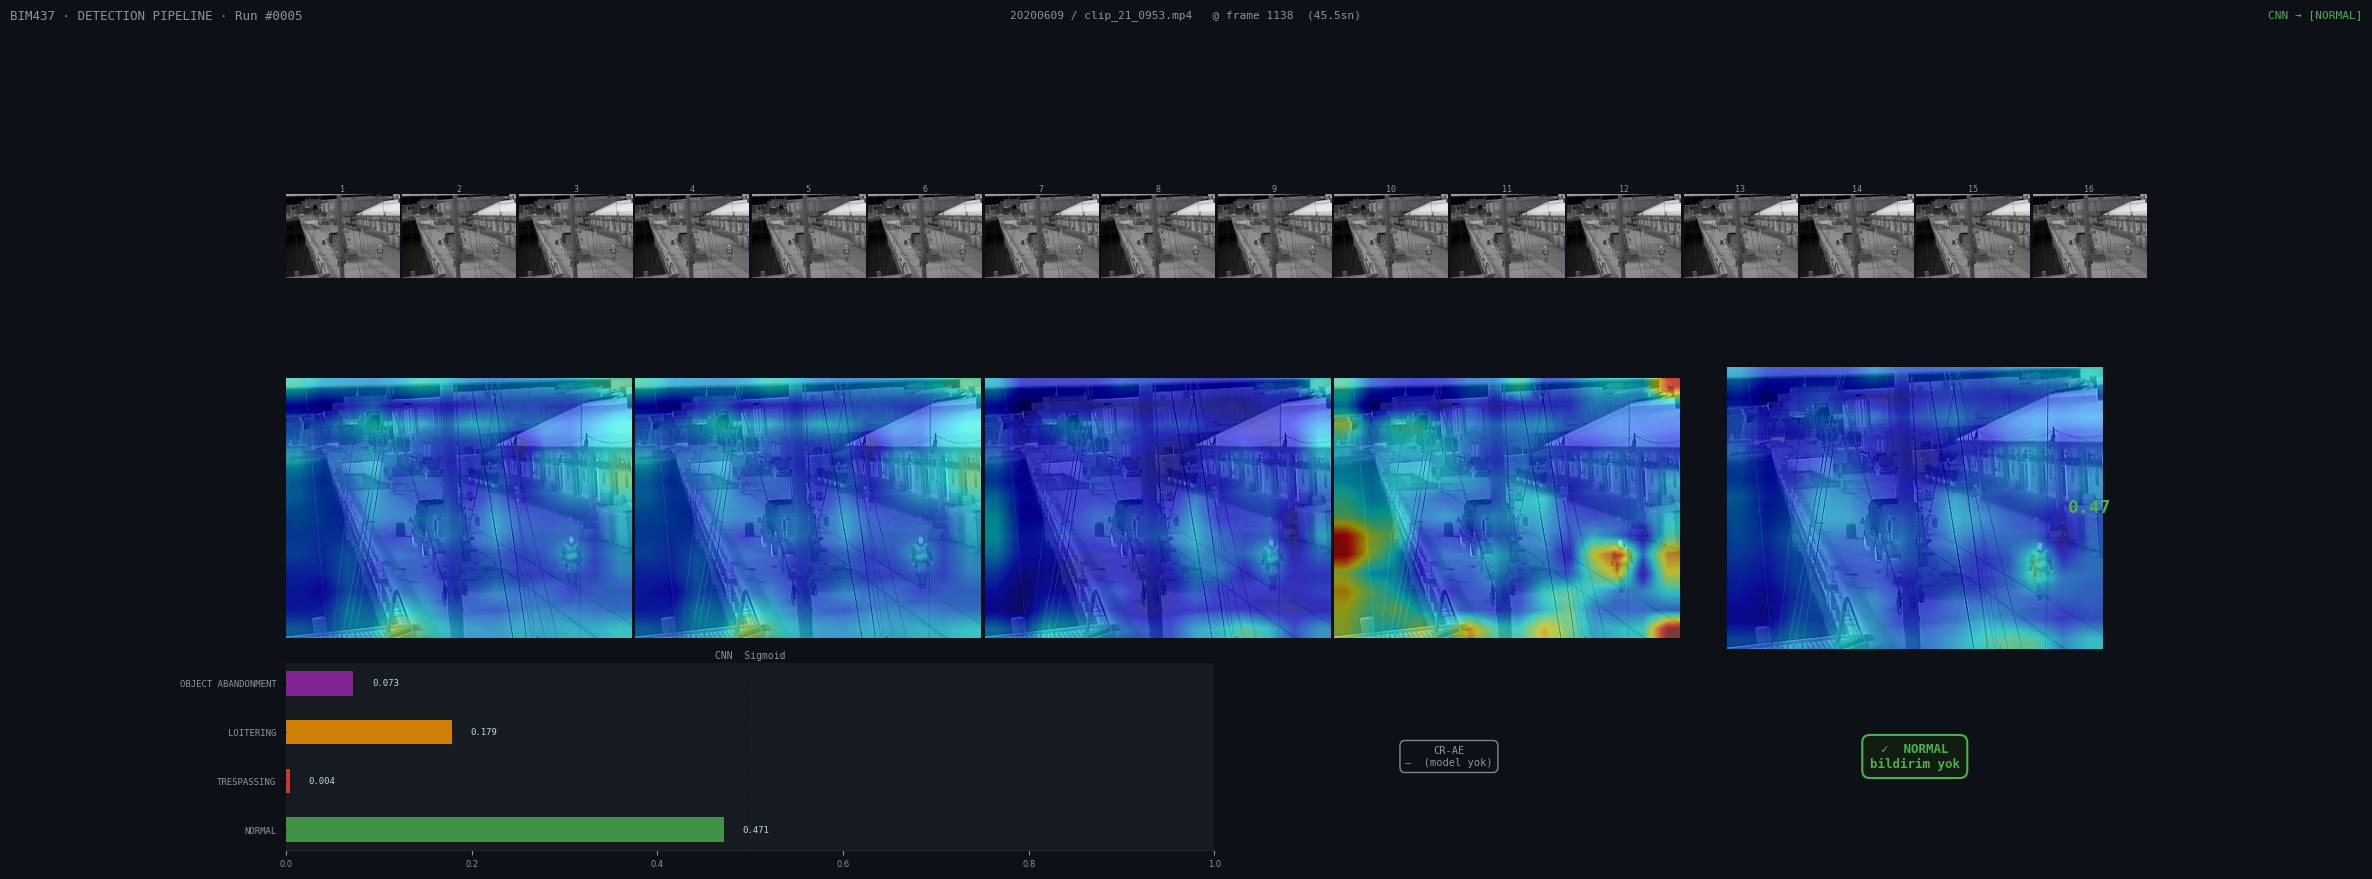


  ✓ Kaydedildi  →  run0005_NORMAL_NRM_20200609_clip_21_0953_f1138.png
  📂 /content/drive/MyDrive/archive/pipeline_results
  Toplam sonuç: 5

════════════════════════════════════════════════════════════



In [31]:
# ═══════════════════════════════════════════════════════════
# BIM437 PIPELINE v2 — Profesyonel Akış
# LTD → preprocess (CRAE:128, CNN:112) → CR-AE → CNN → GradCAM
# Her çalıştırmada 1 klip, sonuç Drive'a kaydedilir
# ═══════════════════════════════════════════════════════════
import torch, torch.nn as nn, numpy as np, cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchvision.models.video import r3d_18
from torch.amp import autocast
from pathlib import Path
import random, time

# ──────────────────────────────────────────────────────────
# AYARLAR
# ──────────────────────────────────────────────────────────
LTD_DIR        = Path("/content/drive/MyDrive/archive/LTD Dataset/LTD Dataset/Video Clips")
CNN_PATH       = "/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn_multilabel_final_model/best_model.pth"
CRAE_PATH = "/content/drive/MyDrive/archive/Data_Subset_Autoencoders_Anomaly_Detectors/models/crae_winter_finetuned2.pth"
RESULT_DIR     = Path("/content/drive/MyDrive/archive/pipeline_results")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES        = ["normal","trespassing","loitering","object_abandonment"]
DEVICE         = torch.device("cuda")
N_FRAMES       = 16
CNN_SIZE       = 112
CRAE_SIZE      = 128
CRAE_THRESHOLD = 0.015

CNN_MEAN  = np.array([0.485,0.456,0.406], dtype=np.float32)
CNN_STD   = np.array([0.229,0.224,0.225], dtype=np.float32)
CRAE_MEAN = np.array([0.5,0.5,0.5],       dtype=np.float32)
CRAE_STD  = np.array([0.5,0.5,0.5],       dtype=np.float32)

COLORS = {
    "normal":             "#4CAF50",
    "trespassing":        "#F44336",
    "loitering":          "#FF9800",
    "object_abandonment": "#9C27B0",
}
ALERT_CLASSES = {"trespassing","object_abandonment"}

BG     = "#0D1117"
PANEL  = "#161B22"
BORDER = "#21262D"
TEXT   = "#C9D1D9"
MUTED  = "#8B949E"

# ──────────────────────────────────────────────────────────
# MODEL YÜKLEME
# ──────────────────────────────────────────────────────────
cnn = r3d_18(weights=None)
cnn.fc = nn.Sequential(nn.Dropout(0.5),
                        nn.Linear(cnn.fc.in_features,4))
ckpt = torch.load(CNN_PATH, map_location=DEVICE)
cnn.load_state_dict(ckpt["model_state"])
cnn  = cnn.to(DEVICE).eval()
print(f"✓ CNN  val_f1={ckpt['val_f1']:.4f}")

crae = None
try:
    crae_ckpt = torch.load(CRAE_PATH, map_location=DEVICE)
    # from your_module import CRAE
    # crae = CRAE(...); crae.load_state_dict(crae_ckpt["model_state"])
    # crae = crae.to(DEVICE).eval()
    print("✓ CR-AE yüklendi")
except Exception as e:
    print(f"⚠  CR-AE yok — her klip CNN'e gönderilir")

_act = {}
cnn.layer3[1].conv2.register_forward_hook(
    lambda m,i,o: _act.update({"v":o})
)
print("✓ Pipeline hazır\n")

# ──────────────────────────────────────────────────────────
# FONKSİYONLAR
# ──────────────────────────────────────────────────────────
def extract_frames(mp4_path, start):
    cap = cv2.VideoCapture(str(mp4_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    frames = []
    for _ in range(N_FRAMES):
        ret,f = cap.read()
        if not ret: break
        frames.append(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames if len(frames)==N_FRAMES else None

def preprocess_cnn(frames):
    fm  = [cv2.resize(f,(CNN_SIZE,CNN_SIZE)) for f in frames]
    arr = (np.stack(fm).astype(np.float32)/255.0 - CNN_MEAN) / CNN_STD
    return torch.from_numpy(arr.transpose(3,0,1,2)).float()

def preprocess_crae(frames):
    fm  = [cv2.resize(f,(CRAE_SIZE,CRAE_SIZE)) for f in frames]
    arr = (np.stack(fm).astype(np.float32)/255.0 - CRAE_MEAN) / CRAE_STD
    return torch.from_numpy(arr.transpose(3,0,1,2)).float()

def infer_crae(t):
    if crae is None: return None, None
    with torch.no_grad():
        inp=t.unsqueeze(0).to(DEVICE); recon=crae(inp)
        err=torch.mean((inp-recon)**2).item()
    return err>CRAE_THRESHOLD, err

def infer_cnn(t):
    with torch.no_grad():
        with autocast('cuda'):
            logits = cnn(t.unsqueeze(0).to(DEVICE))
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    pred    = int(probs.argmax())
    active  = [CLASSES[i] for i in range(4) if probs[i]>0.5]
    if not active: active=[CLASSES[pred]]
    alerts  = [c for c in active if c in ALERT_CLASSES]
    return pred, probs, active, alerts

def gradcam_pp(t, target):
    cnn.eval()
    inp=t.unsqueeze(0).to(DEVICE); logits=cnn(inp); act=_act["v"]
    try:
        g=torch.autograd.grad(logits[0,target],act,
                               retain_graph=True,create_graph=False)[0][0]
    except: return None
    a=act[0].detach(); gsq=g**2; gcu=g**3
    den=2*gsq+(a*gcu).sum(dim=(2,3),keepdim=True)
    den=torch.where(den!=0,den,torch.ones_like(den))
    w=(gsq/den*torch.relu(g)).mean(dim=(2,3),keepdim=True)
    cam=torch.relu((w*a).sum(0)).cpu().numpy()
    if cam.max()<=1e-6: return None
    return (cam-cam.min())/(cam.max()-cam.min()+1e-8)

def jet_overlay(frame, cam_2d, alpha=0.55):
    H,W=frame.shape[:2]
    cr=cv2.resize(cam_2d.astype(np.float32),(W,H))
    hm=cv2.cvtColor(cv2.applyColorMap((cr*255).astype(np.uint8),
                     cv2.COLORMAP_JET),cv2.COLOR_BGR2RGB)
    return (alpha*hm+(1-alpha)*frame).astype(np.uint8)

def cam_fi(cam,fi):
    T=cam.shape[0]; return cam[min(int(fi*T/N_FRAMES),T-1)]

# ──────────────────────────────────────────────────────────
# GÖRSEL — Profesyonel panel
# ──────────────────────────────────────────────────────────
def render_and_save(frames, probs, active, alerts, cnn_t,
                    crae_res, info, run_id):

    active_idx = [CLASSES.index(c) for c in active if c in CLASSES]
    n_cam_rows = len(active_idx)
    # Layout: başlık + 16 frame + gradcam satırları + alt bar
    fig = plt.figure(figsize=(24, 3.5 + n_cam_rows*3.2 + 2.8),
                     facecolor=BG)

    total_rows  = 1 + n_cam_rows + 1
    height_rats = [1.5] + [1.8]*n_cam_rows + [1.2]
    gs = gridspec.GridSpec(total_rows, 16,
                           figure=fig, hspace=0.06, wspace=0.03,
                           height_ratios=height_rats)

    # ── Satır 0: 16 frame ───────────────────────────────
    for fi in range(N_FRAMES):
        ax = fig.add_subplot(gs[0, fi])
        ax.imshow(frames[fi])
        ax.axis('off')
        ax.set_title(str(fi+1), fontsize=6, color=MUTED,
                     pad=1, fontfamily='monospace')
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor(BORDER)
            sp.set_linewidth(0.4)

    # ── Satır 1..N: GradCAM (5 temsili frame) ───────────
    SHOW = [0,3,7,11,15]
    for row_i, ai in enumerate(active_idx):
        cname = CLASSES[ai]
        color = COLORS[cname]
        cam   = gradcam_pp(cnn_t, ai)

        for col_i, fi in enumerate(SHOW):
            span_s = col_i*3
            span_e = span_s+3 if col_i<4 else 16
            ax = fig.add_subplot(gs[1+row_i, span_s:span_e])
            frame = frames[fi]
            if cam is not None:
                ax.imshow(jet_overlay(frame, cam_fi(cam,fi)))
            else:
                ax.imshow(frame)
            ax.axis('off')
            if col_i==0:
                ax.set_ylabel(
                    cname.replace('_','\n').upper(),
                    fontsize=6.5, color=color,
                    fontfamily='monospace',
                    rotation=0, ha='right', va='center',
                    labelpad=58)
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_edgecolor(color if col_i==0 else BORDER)
                sp.set_linewidth(0.8 if col_i==0 else 0.3)

        # Prob etiketi sağ
        ax_p = fig.add_subplot(gs[1+row_i, 15])
        ax_p.set_facecolor(PANEL); ax_p.axis('off')
        ax_p.text(0.5,0.5, f"{probs[ai]:.2f}",
                  ha='center',va='center',
                  fontsize=13,fontweight='bold',color=color,
                  fontfamily='monospace',
                  transform=ax_p.transAxes)

    # ── Alt panel ────────────────────────────────────────
    # Prob bars (0:8)
    ax_b = fig.add_subplot(gs[-1,:8])
    ax_b.set_facecolor(PANEL)
    bcolors = [COLORS[c] for c in CLASSES]
    ax_b.barh(range(4), probs, color=bcolors, alpha=0.8,
              height=0.5, edgecolor='none')
    ax_b.set_yticks(range(4))
    ax_b.set_yticklabels([c.replace('_',' ').upper() for c in CLASSES],
                          fontsize=6.5, color=MUTED, fontfamily='monospace')
    ax_b.set_xlim(0,1)
    ax_b.axvline(0.5, color=BORDER, lw=0.8, ls='--')
    ax_b.tick_params(axis='x', colors=MUTED, labelsize=6)
    for sp in ['top','right','left']: ax_b.spines[sp].set_visible(False)
    ax_b.spines['bottom'].set_color(BORDER)
    ax_b.set_facecolor(PANEL)
    for i,p in enumerate(probs):
        ax_b.text(min(p+0.02,0.93),i,f"{p:.3f}",
                  va='center',fontsize=6.5,color=TEXT,
                  fontfamily='monospace')
    ax_b.set_title("CNN  Sigmoid", fontsize=7, color=MUTED,
                   fontfamily='monospace', pad=3)

    # CR-AE box (8:12)
    ax_cr = fig.add_subplot(gs[-1,8:12])
    ax_cr.set_facecolor(PANEL); ax_cr.axis('off')
    if crae_res[1] is None:
        cr_txt = "CR-AE\n—  (model yok)"; cr_col = MUTED
    else:
        cr_txt = (f"CR-AE\nerr={crae_res[1]:.5f}\n"
                  f"thr={CRAE_THRESHOLD}\n"
                  f"{'● ANOMALİ' if crae_res[0] else '○ NORMAL'}")
        cr_col = "#F44336" if crae_res[0] else "#4CAF50"
    ax_cr.text(0.5,0.5,cr_txt,ha='center',va='center',
               fontsize=7.5,color=cr_col,fontfamily='monospace',
               transform=ax_cr.transAxes,
               bbox=dict(boxstyle='round,pad=0.5',
                         facecolor=BG,edgecolor=cr_col,alpha=0.9))

    # Karar (12:16)
    ax_d = fig.add_subplot(gs[-1,12:])
    ax_d.set_facecolor(PANEL); ax_d.axis('off')
    if alerts:
        dt  = "🚨  ALERT\n" + "\n".join([a.replace('_',' ').upper() for a in alerts])
        dc  = "#FF4444"; db = "#2D1010"; de = "#FF4444"
    else:
        dt  = "✓  NORMAL\nbildirim yok"
        dc  = "#4CAF50"; db = "#101D10"; de = "#4CAF50"
    ax_d.text(0.5,0.5,dt,ha='center',va='center',
              fontsize=9,fontweight='bold',color=dc,
              fontfamily='monospace',transform=ax_d.transAxes,
              bbox=dict(boxstyle='round,pad=0.6',
                        facecolor=db,edgecolor=de,linewidth=1.5))

    # ── Üst başlık şeridi ───────────────────────────────
    active_str = " + ".join([c.replace('_',' ').upper() for c in active])
    fig.text(0.01, 0.995,
             f"BIM437 · DETECTION PIPELINE · Run #{run_id:04d}",
             fontsize=9, color=MUTED, fontfamily='monospace',
             va='top')
    fig.text(0.5, 0.995,
             f"{info['day']} / {info['video']}   "
             f"@ frame {info['start']}  ({info['time']})",
             fontsize=8, color=MUTED, fontfamily='monospace',
             va='top', ha='center')
    fig.text(0.99, 0.995,
             f"CNN → [{active_str}]",
             fontsize=8,
             color="#F44336" if alerts else "#4CAF50",
             fontfamily='monospace', va='top', ha='right')

    plt.tight_layout(rect=[0,0,1,0.993])

    status = "ALERT" if alerts else "NORMAL"
    ac_str = "+".join([a[:3].upper() for a in alerts]) if alerts else "NRM"
    fname  = (f"run{run_id:04d}_{status}_{ac_str}_"
              f"{info['day']}_{info['video'][:12]}_f{info['start']}.png")
    fpath  = RESULT_DIR/fname
    plt.savefig(str(fpath),dpi=130,bbox_inches='tight',facecolor=BG)
    plt.show()
    return str(fpath)

# ──────────────────────────────────────────────────────────
# ANA PIPELINE
# ──────────────────────────────────────────────────────────
def run_pipeline():
    SEP = "═"*60
    print(f"\n{SEP}")
    print("  BIM437  ·  THERMAL ANOMALY DETECTION  PIPELINE")
    print(f"{SEP}")

    # 1. LTD random klip
    day_dirs = [d for d in LTD_DIR.iterdir() if d.is_dir()]
    day_dir  = random.choice(day_dirs)
    mp4s     = list(day_dir.glob("*.mp4"))
    if not mp4s: print("  ✗ MP4 yok"); return
    mp4 = random.choice(mp4s)
    cap = cv2.VideoCapture(str(mp4))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    start  = random.randint(0, max(0,total-N_FRAMES-1))
    frames = extract_frames(mp4, start)
    if frames is None: print("  ✗ Frame yok"); return

    info = {"day":day_dir.name,"video":mp4.name,
            "start":start,"time":f"{start/fps:.1f}sn" if fps>0 else "?"}
    print(f"\n  📁 {info['day']}  /  {info['video']}")
    print(f"  🎞  frame={start}  t={info['time']}  ({total} toplam)")

    # 2. Preprocess
    print(f"\n  [1/4] Preprocess ──────────────────────────────")
    cnn_t  = preprocess_cnn(frames)
    crae_t = preprocess_crae(frames)
    print(f"  CNN  tensor : {tuple(cnn_t.shape)}  (normalized ImageNet)")
    print(f"  CRAE tensor : {tuple(crae_t.shape)}  (normalized ±1)")

    # 3. CR-AE
    print(f"\n  [2/4] CR-AE ────────────────────────────────────")
    t0 = time.time()
    anomali, recon_err = infer_crae(crae_t)
    elapsed = time.time()-t0
    if recon_err is not None:
        bar_len = int((recon_err/CRAE_THRESHOLD)*20)
        bar     = "█"*min(bar_len,30)
        print(f"  err={recon_err:.5f}  thr={CRAE_THRESHOLD}  {elapsed:.3f}sn")
        print(f"  [{bar}]  {'ANOMALİ ✓' if anomali else 'NORMAL ✗'}")
        if not anomali:
            print(f"\n  ╔══════════════════════════════════╗")
            print(f"  ║  CR-AE: NORMAL  →  klip atlandı  ║")
            print(f"  ╚══════════════════════════════════╝\n")
            return
    else:
        print(f"  CR-AE yok → devam ({elapsed:.3f}sn)")

    # 4. CNN
    print(f"\n  [3/4] CNN ──────────────────────────────────────")
    t0 = time.time()
    pred_idx, probs, active, alerts = infer_cnn(cnn_t)
    elapsed = time.time()-t0
    print(f"  {elapsed:.3f}sn")
    for i,c in enumerate(CLASSES):
        bar = "█"*int(probs[i]*30)
        star= " ◄ ALERT" if c in ALERT_CLASSES and probs[i]>0.5 else ""
        print(f"  {c:<22} [{bar:<30}] {probs[i]:.3f}{star}")

    # 5. Karar
    print(f"\n  [4/4] Karar ────────────────────────────────────")
    if alerts:
        print(f"  ┌─────────────────────────────────────┐")
        print(f"  │  🚨  ALERT: {str(alerts):<26}│")
        print(f"  │  Operatöre bildirim gönderiliyor    │")
        print(f"  └─────────────────────────────────────┘")
    else:
        print(f"  ┌─────────────────────────────────────┐")
        print(f"  │  ✓  NORMAL — operatör bildirimi yok │")
        print(f"  └─────────────────────────────────────┘")

    # 6. Render + Save
    run_id = len(list(RESULT_DIR.glob("run*.png")))+1
    fpath  = render_and_save(
        frames, probs, active, alerts, cnn_t,
        (anomali, recon_err), info, run_id
    )
    print(f"\n  ✓ Kaydedildi  →  {Path(fpath).name}")
    print(f"  📂 {RESULT_DIR}")
    print(f"  Toplam sonuç: {len(list(RESULT_DIR.glob('run*.png')))}")
    print(f"\n{SEP}\n")

# ──────────────────────────────────────────────────────────
run_pipeline()